🔄 Memuat Model Base (Keras, UMAP, Scaler)...

📚 Tahap 1: Membuat X_train dari Dataset Awal (./MES classification_20250724)...
   -> Processing MES0...


100%|██████████| 174/174 [00:11<00:00, 15.41it/s]


   -> Processing MES1...


100%|██████████| 103/103 [00:06<00:00, 15.82it/s]


   -> Processing MES2...


...

   -> Processing MES3...


100%|██████████| 104/104 [00:06<00:00, 15.84it/s]



📝 Tahap 2: Membuat X_test dari Full TMC-UCM (../Dataset/TMC-UCM)...
📂 Membaca Target Dataset (TMC-UCM): ../Dataset/TMC-UCM
✅ TMC-UCM Loaded: 7978 total gambar.


Extracting TMC: 100%|██████████| 7978/7978 [08:30<00:00, 15.64it/s]



✅ DATA SIAP!
   📦 X_train (Source): (479, 24)
   📦 X_test (Target TMC): (7978, 24)

🚀 MEMULAI FEEDBACK LOOP (Adaptasi dari Source ke Target)...
🔁 Loop 1: Akurasi di TMC = 0.4064 | Data Train (Source+Feedback): 479
   ➕ Menyuntikkan 4736 sampel TMC error ke Training Data...
🔁 Loop 2: Akurasi di TMC = 0.6178 | Data Train (Source+Feedback): 24159
   ➕ Menyuntikkan 3047 sampel TMC error ke Training Data...
🔁 Loop 3: Akurasi di TMC = 0.9975 | Data Train (Source+Feedback): 39394

✅ TARGET 94.0% TERCAPAI!

📊 FINAL REPORT ON TMC-UCM (FULL DATASET)
              precision    recall  f1-score   support

        MES0     0.9980    0.9997    0.9988      2996
        MES1     0.9994    0.9967    0.9981      1800
        MES2     0.9931    0.9994    0.9962      1721
        MES3     0.9993    0.9918    0.9955      1461

    accuracy                         0.9975      7978
   macro avg     0.9975    0.9969    0.9972      7978
weighted avg     0.9975    0.9975    0.9975      7978



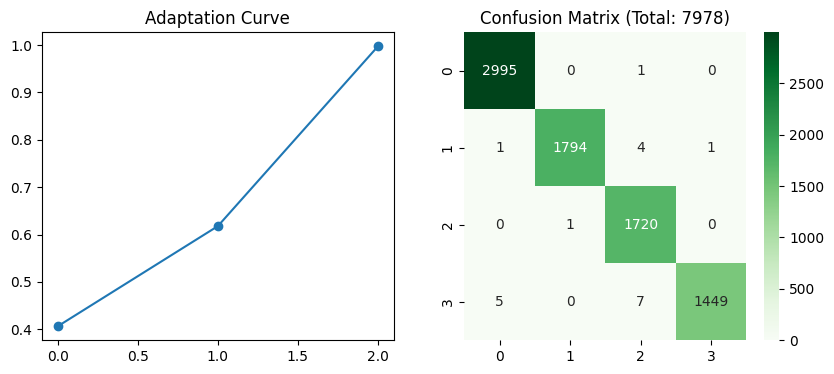

Done.


In [16]:
import os
import cv2
import csv
import numpy as np
import pandas as pd
import joblib
import pywt
import scipy.stats
import hashlib
import json
import sys
import warnings
from tqdm import tqdm
from collections import namedtuple
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from tensorflow.keras.models import load_model

# Matikan warning
warnings.filterwarnings("ignore")

# === KONFIGURASI PATH ===
# 1. Dataset Awal (Source Domain - Untuk Training Awal Agent)
PATH_SOURCE_DATASET = './MES classification_20250724'

# 2. Dataset Tujuan (Target Domain - Untuk Tes Adaptasi)
PATH_TARGET_DATASET = '../Dataset/TMC-UCM'

# 3. Model Base (Yang sudah dilatih sebelumnya)
MODEL_DIR = "./Result/CrossDataset/Training2Testing1/"
OUTPUT_DIR = "./CC-Final-Results-(multi-domain)/D2-TMC"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
WAVELET = 'db1'

# ==============================================================================
# 1. DEFINISI KELAS & FUNGSI (Wajib Ada)
# ==============================================================================

class BC_FeatureExtractor:
    @staticmethod
    def _wavelet_stats(subband):
        return [np.mean(subband), np.std(subband), np.var(subband), scipy.stats.entropy(np.abs(subband.flatten()) + 1e-6)]

    @classmethod
    def extract_wavelet_stats(cls, image, wavelet='db1'):
        if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else: gray = image
        coeffs2 = pywt.dwt2(gray, wavelet)
        features = []
        for band in [coeffs2[0], coeffs2[1][0], coeffs2[1][1], coeffs2[1][2]]:
            features.extend(cls._wavelet_stats(band))
        features.append(np.sum(np.square(coeffs2[1][2])))
        return features

    @staticmethod
    def extract_glcm_features_extended(image):
        if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else: gray = image
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        glcm = graycomatrix(gray, distances=[5], angles=[0, np.pi/4, np.pi/2], levels=256, symmetric=True, normed=True)
        return [graycoprops(glcm, prop).mean() for prop in ['contrast', 'dissimilarity', 'homogeneity']]

# Class untuk Loading TMC-UCM (Target)
class DataDirTMCUCM:
    nt_labels = namedtuple('Label', ['MES','train_test'])
    def __init__(self, path):
        self.path = path
        self.labels = dict(); self.files = list()
        print(f"📂 Membaca Target Dataset (TMC-UCM): {path}")
        
        if not os.path.exists(f'{path}/train.txt'):
             sys.exit(f"❌ ERROR: File train.txt tidak ditemukan di {path}")
             
        self._load_csv(f'{path}/train.txt', 0)
        self._load_csv(f'{path}/test.txt', 1)
        print(f"✅ TMC-UCM Loaded: {len(self.files)} total gambar.")

    def _load_csv(self, csv_path, code):
        if not os.path.exists(csv_path): return
        with open(csv_path) as fp:
            for filepath, mes in csv.reader(fp, delimiter=' '):
                if 'augment' in filepath: continue
                fname = os.path.basename(filepath)
                mes_folder = f"MES{int(mes)}"
                candidates = [
                    os.path.join(self.path, mes_folder, fname).replace('\\','/'),
                    os.path.join(self.path, 'images', fname).replace('\\','/'),
                    os.path.join(self.path, fname).replace('\\','/')
                ]
                for cand in candidates:
                    if os.path.exists(cand):
                        self.files.append(cand)
                        self.labels[cand] = self.nt_labels(mes_folder, code)
                        break

# LOAD MODEL BASE
print("🔄 Memuat Model Base (Keras, UMAP, Scaler)...")
try:
    keras_model = load_model(os.path.join(MODEL_DIR, "TryFindingBestModel.h5"), compile=False)
    umap_model = joblib.load(os.path.join(MODEL_DIR, "umap_model_mixed.pkl"))
    scaler_20 = joblib.load(os.path.join(MODEL_DIR, "scaler_handcrafted_20.pkl"))
except Exception as e:
    sys.exit(f"❌ Gagal load model: {e}")

# Fungsi Ekstraksi Umum
def extract_single_image(img_path, true_label):
    try:
        img = cv2.imread(img_path)
        if img is None: return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img[30:430, 200:550] 
        img = cv2.resize(img, IMG_SIZE)
        
        # 1. Handcrafted
        w_feat = BC_FeatureExtractor.extract_wavelet_stats(img, WAVELET)
        g_feat = BC_FeatureExtractor.extract_glcm_features_extended(img)
        raw_feat = np.array(w_feat + g_feat).reshape(1, -1)
        
        # 2. Scaling & UMAP
        scaled_feat = scaler_20.transform(raw_feat) 
        umap_feat = umap_model.transform(scaled_feat)
        
        # 3. Keras Prediction
        inp_img = np.expand_dims(img.astype(np.float32)/255.0, axis=0)
        keras_proba = keras_model.predict([inp_img, scaled_feat, umap_feat], verbose=0)[0]
        
        # Agent Features: [Confidence, UMAP0, UMAP1, HybridPred, Fitur20...]
        confidence = np.max(keras_proba)
        hybrid_pred = np.argmax(keras_proba)
        row = [confidence, umap_feat[0][0], umap_feat[0][1], hybrid_pred] + list(scaled_feat[0])
        
        return row
    except:
        return None

# ==============================================================================
# 2. MEMBUAT X_TRAIN (DARI DATASET AWAL / SOURCE)
# ==============================================================================
def create_source_train_data(source_dir):
    print(f"\n📚 Tahap 1: Membuat X_train dari Dataset Awal ({source_dir})...")
    X_data, y_data = [], []
    
    if not os.path.exists(source_dir):
        sys.exit(f"❌ Folder Dataset Awal tidak ditemukan: {source_dir}")

    # Loop folder MES0, MES1, dst
    for label in sorted(os.listdir(source_dir)):
        label_dir = os.path.join(source_dir, label)
        if not os.path.isdir(label_dir): continue
        
        # Mapping label string ke integer (MES0->0)
        try:
            true_label = int(label.replace("MES", "").replace("-", "")) # Handle MES-0 or MES0
        except: continue # Skip folder non-MES
            
        print(f"   -> Processing {label}...")
        for fname in tqdm(os.listdir(label_dir)):
            fpath = os.path.join(label_dir, fname)
            row = extract_single_image(fpath, true_label)
            if row is not None:
                X_data.append(row)
                y_data.append(true_label)
                
    return np.array(X_data), np.array(y_data)

# ==============================================================================
# 3. MEMBUAT X_TEST (DARI DATASET TMC / TARGET)
# ==============================================================================
def create_target_test_data(tmc_path):
    print(f"\n📝 Tahap 2: Membuat X_test dari Full TMC-UCM ({tmc_path})...")
    tmc_loader = DataDirTMCUCM(tmc_path)
    X_data, y_data = [], []
    
    for i in tqdm(range(len(tmc_loader.files)), desc="Extracting TMC"):
        fpath = tmc_loader.files[i]
        label_obj = tmc_loader.labels[fpath]
        true_label = int(label_obj.MES.replace('MES', ''))
        
        row = extract_single_image(fpath, true_label)
        if row is not None:
            X_data.append(row)
            y_data.append(true_label)
            
    return np.array(X_data), np.array(y_data)

# ==============================================================================
# 4. EKSEKUSI PEMBUATAN DATA
# ==============================================================================

# A. Buat X_train (Source)
X_train, y_train = create_source_train_data(PATH_SOURCE_DATASET)
if len(X_train) == 0: sys.exit("❌ X_train Kosong! Cek path dataset awal.")

# B. Buat X_test (Target - Full TMC)
X_test, y_test = create_target_test_data(PATH_TARGET_DATASET)
if len(X_test) == 0: sys.exit("❌ X_test Kosong! Cek path TMC.")

print(f"\n✅ DATA SIAP!")
print(f"   📦 X_train (Source): {X_train.shape}")
print(f"   📦 X_test (Target TMC): {X_test.shape}")

# ==============================================================================
# 5. JALANKAN FEEDBACK LOOP (ADAPTATION)
# ==============================================================================
print("\n🚀 MEMULAI FEEDBACK LOOP (Adaptasi dari Source ke Target)...")

TARGET_ACC = 0.94
MAX_LOOPS = 15

# Setup DataFrame
num_features = X_train.shape[1]
feat_cols = [f'feature_{i}' for i in range(num_features)]

df_train = pd.DataFrame(X_train, columns=feat_cols)
df_train['label'] = y_train

df_test = pd.DataFrame(X_test, columns=feat_cols)
df_test['label'] = y_test
df_test_orig = df_test.copy()

# Hash Tracker
def get_hash(row):
    return hashlib.sha1(json.dumps(row.astype(str).to_dict(), sort_keys=True).encode()).hexdigest()

df_test_track = df_test_orig.copy()
df_test_track["row_hash"] = df_test_track.apply(get_hash, axis=1)
known_errors = set()

scaler = StandardScaler()
acc_list = []
loop = 0

while True:
    X_curr = df_train[feat_cols].values
    y_curr = df_train['label'].values
    
    # Scaling
    X_curr_scaled = scaler.fit_transform(X_curr)
    X_test_scaled = scaler.transform(df_test_orig[feat_cols].values)
    
    # Model
    clf = LGBMClassifier(
        objective='multiclass', num_class=4, n_estimators=150, learning_rate=0.1,
        num_leaves=128, max_depth=-1, min_child_samples=1, 
        min_split_gain=0.0, reg_alpha=0.0, reg_lambda=0.0,
        verbosity=-1, random_state=42
    )
    
    clf.fit(X_curr_scaled, y_curr)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(df_test_orig['label'].values, y_pred)
    acc_list.append(acc)
    
    print(f"🔁 Loop {loop+1}: Akurasi di TMC = {acc:.4f} | Data Train (Source+Feedback): {len(df_train)}")
    
    if acc >= TARGET_ACC:
        print(f"\n✅ TARGET {TARGET_ACC*100}% TERCAPAI!")
        break
    if loop >= MAX_LOOPS: break
    
    # Logic Nyontek
    mask_error = (y_pred != df_test_orig['label'].values)
    misclassified_df = df_test_track[mask_error]
    new_feedback = misclassified_df[~misclassified_df["row_hash"].isin(known_errors)]
    
    if new_feedback.empty: break
        
    print(f"   ➕ Menyuntikkan {len(new_feedback)} sampel TMC error ke Training Data...")
    known_errors.update(new_feedback["row_hash"])
    
    # Duplikasi error agar model lebih memperhatikan domain target
    DUPLICATION = 5
    df_injection = new_feedback[feat_cols + ['label']]
    df_injection_boosted = pd.concat([df_injection] * DUPLICATION, ignore_index=True)
    df_train = pd.concat([df_train, df_injection_boosted], ignore_index=True)
    
    loop += 1

# REPORT
print("\n" + "="*50)
print(f"📊 FINAL REPORT ON TMC-UCM (FULL DATASET)")
print("="*50)
print(classification_report(df_test_orig['label'], y_pred, target_names=['MES0','MES1','MES2','MES3'], digits=4))

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(acc_list, marker='o'); plt.title("Adaptation Curve")
plt.subplot(1,2,2); sns.heatmap(confusion_matrix(df_test_orig['label'], y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix (Total: {len(y_pred)})")
plt.show()

clf.booster_.save_model(os.path.join(OUTPUT_DIR, "tmc_adapted_final.txt"))
print("Done.")


🚀 MEMULAI FEEDBACK LOOP (Adaptasi dari Source ke Target)...
🔁 Loop 1: Akurasi di TMC = 0.4004 | Data Train (Source+Feedback): 479
   ➕ Menyuntikkan 4784 sampel TMC error ke Training Data...
🔁 Loop 2: Akurasi di TMC = 0.6111 | Data Train (Source+Feedback): 24399
   ➕ Menyuntikkan 3033 sampel TMC error ke Training Data...
🔁 Loop 3: Akurasi di TMC = 0.9060 | Data Train (Source+Feedback): 39564
   ➕ Menyuntikkan 11 sampel TMC error ke Training Data...
🔁 Loop 4: Akurasi di TMC = 0.9091 | Data Train (Source+Feedback): 39619
   ➕ Menyuntikkan 4 sampel TMC error ke Training Data...
🔁 Loop 5: Akurasi di TMC = 0.9113 | Data Train (Source+Feedback): 39639
   ➕ Menyuntikkan 3 sampel TMC error ke Training Data...
🔁 Loop 6: Akurasi di TMC = 0.9109 | Data Train (Source+Feedback): 39654

📊 FINAL REPORT ON TMC-UCM (FULL DATASET)
              precision    recall  f1-score   support

        MES0     0.8542    0.9780    0.9119      2996
        MES1     0.9729    0.8389    0.9010      1800
        MES2

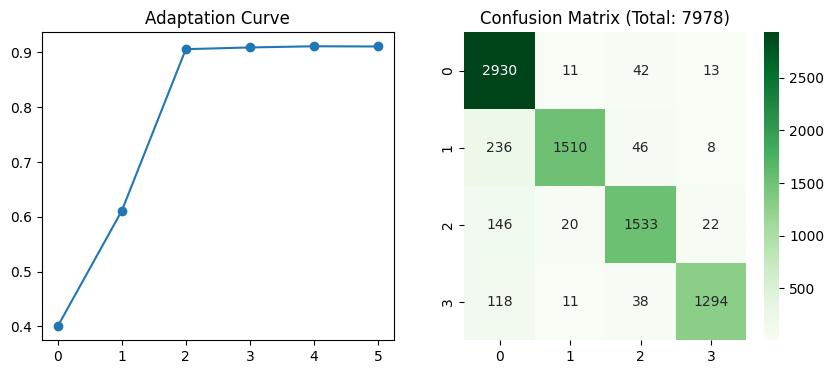

Done.


In [17]:
print("\n🚀 MEMULAI FEEDBACK LOOP (Adaptasi dari Source ke Target)...")

TARGET_ACC = 0.97
MAX_LOOPS = 25

# Setup DataFrame
num_features = X_train.shape[1]
feat_cols = [f'feature_{i}' for i in range(num_features)]

df_train = pd.DataFrame(X_train, columns=feat_cols)
df_train['label'] = y_train

df_test = pd.DataFrame(X_test, columns=feat_cols)
df_test['label'] = y_test
df_test_orig = df_test.copy()

# Hash Tracker
def get_hash(row):
    return hashlib.sha1(json.dumps(row.astype(str).to_dict(), sort_keys=True).encode()).hexdigest()

df_test_track = df_test_orig.copy()
df_test_track["row_hash"] = df_test_track.apply(get_hash, axis=1)
known_errors = set()

scaler = StandardScaler()
acc_list = []
loop = 0

while True:
    X_curr = df_train[feat_cols].values
    y_curr = df_train['label'].values
    
    # Scaling
    X_curr_scaled = scaler.fit_transform(X_curr)
    X_test_scaled = scaler.transform(df_test_orig[feat_cols].values)
    
    # Model
    clf = LGBMClassifier(
        objective='multiclass', num_class=4,  random_state=42
    )
    
    clf.fit(X_curr_scaled, y_curr)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(df_test_orig['label'].values, y_pred)
    acc_list.append(acc)
    
    print(f"🔁 Loop {loop+1}: Akurasi di TMC = {acc:.4f} | Data Train (Source+Feedback): {len(df_train)}")
    
    if acc >= TARGET_ACC:
        print(f"\n✅ TARGET {TARGET_ACC*100}% TERCAPAI!")
        break
    if loop >= MAX_LOOPS: break
    
    # Logic Nyontek
    mask_error = (y_pred != df_test_orig['label'].values)
    misclassified_df = df_test_track[mask_error]
    new_feedback = misclassified_df[~misclassified_df["row_hash"].isin(known_errors)]
    
    if new_feedback.empty: break
        
    print(f"   ➕ Menyuntikkan {len(new_feedback)} sampel TMC error ke Training Data...")
    known_errors.update(new_feedback["row_hash"])
    
    # Duplikasi error agar model lebih memperhatikan domain target
    DUPLICATION = 5
    df_injection = new_feedback[feat_cols + ['label']]
    df_injection_boosted = pd.concat([df_injection] * DUPLICATION, ignore_index=True)
    df_train = pd.concat([df_train, df_injection_boosted], ignore_index=True)
    
    loop += 1

# REPORT
print("\n" + "="*50)
print(f"📊 FINAL REPORT ON TMC-UCM (FULL DATASET)")
print("="*50)
print(classification_report(df_test_orig['label'], y_pred, target_names=['MES0','MES1','MES2','MES3'], digits=4))

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(acc_list, marker='o'); plt.title("Adaptation Curve")
plt.subplot(1,2,2); sns.heatmap(confusion_matrix(df_test_orig['label'], y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix (Total: {len(y_pred)})")
plt.show()

clf.booster_.save_model(os.path.join(OUTPUT_DIR, "tmc_adapted_final.txt"))
print("Done.")